In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from src.config import load_abm_sim_cfg
from src.paths import BM_RESULTS_DIR, ABM_SIM_FIG_DIR, ABM_SIM_RES_DIR

from abm.experiments.experiment_runner import ExperimentRunner
from abm.plotting.cell_plotter import plot_cell, plot_cells_grid

from abm.plotting.timeseries_plotter import *

sim_cfg = load_abm_sim_cfg()
runner = ExperimentRunner(sim_cfg, BM_RESULTS_DIR)

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [2]:
all_result = runner.run_all()
ss_df = all_result['cell_ss_df']

>>> INFO: Running perturbation: WT for 3000 steps.
 WT ar=1.637 | rho_balance=0.013 | rhoa=0.499 | rhoc=0.486 | t=3.6s
>>> INFO: Running perturbation: DSP_KO for 3000 steps.
 DSP_KO ar=1.914 | rho_balance=-0.263 | rhoa=0.307 | rhoc=0.570 | t=3.1s
>>> INFO: Running perturbation: TJP1_KO for 3000 steps.
 TJP1_KO ar=1.461 | rho_balance=0.279 | rhoa=0.581 | rhoc=0.302 | t=3.5s
>>> INFO: Running perturbation: JCAD_KO for 3000 steps.
 JCAD_KO ar=1.669 | rho_balance=-0.001 | rhoa=0.449 | rhoc=0.450 | t=3.2s
>>> INFO: Running perturbation: DSP_JCAD_DKO for 3000 steps.
 DSP_JCAD_DKO ar=1.838 | rho_balance=-0.175 | rhoa=0.339 | rhoc=0.514 | t=3.0s
>>> INFO: Running perturbation: TJP1_JCAD_DKO for 3000 steps.
 TJP1_JCAD_DKO ar=1.539 | rho_balance=0.170 | rhoa=0.512 | rhoc=0.342 | t=3.1s


In [5]:
ss_df = all_result['cell_ss_df']
ss_df

,step,time,perturbation,cell_id,ar,area_ratio,major,minor,rhoa_mean,rhoc_mean,...,t_load_polar,t_load_lat,cortex_T_mean,cortex_a_mean,cortex_force_spread,sf_T,sf_a,sf_squeeze,activation_balance,tension_balance
0,2999,299.9,WT,0,1.637,0.9994,30.238,18.475,0.499,0.486,...,10.866,1.991,0.918,0.801,-0.304,11.660,0.567,3.498,0.234,-3.667
1,2999,299.9,DSP_KO,0,1.914,1.0008,32.383,16.917,0.307,0.570,...,11.933,1.782,0.815,0.858,-0.339,13.835,0.525,4.150,0.333,-4.085
2,2999,299.9,TJP1_KO,0,1.461,0.9985,28.703,19.652,0.581,0.302,...,9.039,2.022,0.943,0.776,-0.262,9.041,0.659,2.712,0.117,-3.261
3,2999,299.9,JCAD_KO,0,1.669,0.9991,30.492,18.275,0.449,0.450,...,10.600,1.894,0.871,0.815,-0.316,11.523,0.585,3.457,0.230,-3.726
4,2999,299.9,DSP_JCAD_DKO,0,1.838,0.9982,31.788,17.296,0.339,0.514,...,11.394,1.790,0.821,0.848,-0.327,12.980,0.553,3.894,0.295,-3.983
5,2999,299.9,TJP1_JCAD_DKO,0,1.539,1.0045,29.488,19.154,0.512,0.342,...,9.477,1.923,0.890,0.797,-0.291,9.856,0.639,2.957,0.158,-3.469


In [6]:
signalling_df = ss_df.loc[:, ['perturbation','rhoa_mean', 'rhoc_mean', 'rho_balance', 
                              'jcad_mean', 'dsp_mean', 'tjp1_mean', 
                              'dsp_spread', 'tjp1_spread',]]
signalling_df

,perturbation,rhoa_mean,rhoc_mean,rho_balance,jcad_mean,dsp_mean,tjp1_mean,dsp_spread,tjp1_spread
0,WT,0.499,0.486,0.013,0.578,0.342,0.331,5.051,7.777
1,DSP_KO,0.307,0.570,-0.263,0.578,0.000,0.331,0.000,9.369
2,TJP1_KO,0.581,0.302,0.279,0.578,0.338,0.000,4.896,0.000
3,JCAD_KO,0.449,0.450,-0.001,0.000,0.339,0.329,5.371,8.358
4,DSP_JCAD_DKO,0.339,0.514,-0.175,0.000,0.000,0.330,0.000,9.364
5,TJP1_JCAD_DKO,0.512,0.342,0.170,0.000,0.337,0.000,5.272,0.000


In [7]:
mech_df = ss_df.loc[:, ['perturbation','t_load_polar', 't_load_lat', 
                        'cortex_force_spread','sf_squeeze', 'cortex_a_mean', 'sf_a',
                        'activation_balance', 'tension_balance']]
mech_df

,perturbation,t_load_polar,t_load_lat,cortex_force_spread,sf_squeeze,cortex_a_mean,sf_a,activation_balance,tension_balance
0,WT,10.866,1.991,-0.304,3.498,0.801,0.567,0.234,-3.667
1,DSP_KO,11.933,1.782,-0.339,4.150,0.858,0.525,0.333,-4.085
2,TJP1_KO,9.039,2.022,-0.262,2.712,0.776,0.659,0.117,-3.261
3,JCAD_KO,10.600,1.894,-0.316,3.457,0.815,0.585,0.230,-3.726
4,DSP_JCAD_DKO,11.394,1.790,-0.327,3.894,0.848,0.553,0.295,-3.983
5,TJP1_JCAD_DKO,9.477,1.923,-0.291,2.957,0.797,0.639,0.158,-3.469


## All Cells Plot

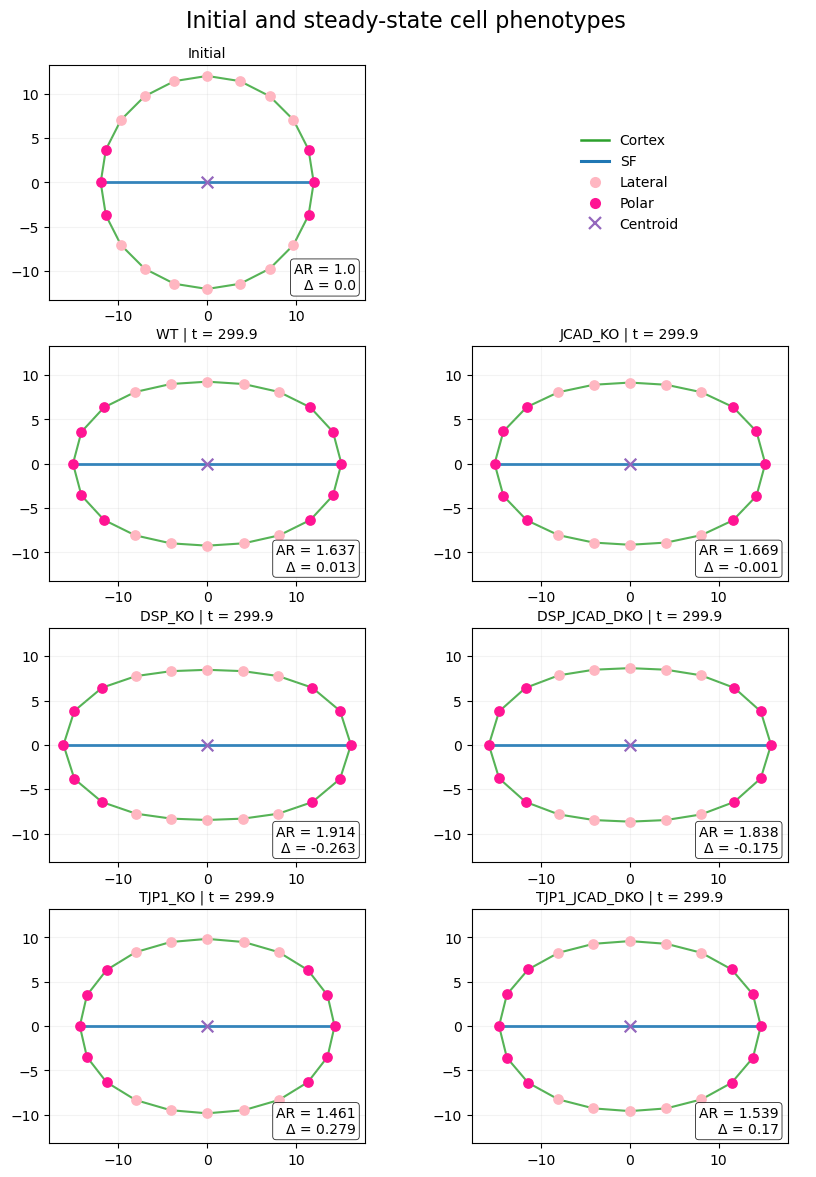

In [8]:
plot_cells_grid(all_result, ABM_SIM_FIG_DIR)

## Timeseries Plots

In [9]:
#cell_ts_df = pd.read_csv(ABM_SIM_RES_DIR / 'abm_cell_timeseries.csv')
cell_ts_df = all_result['cell_ts_df']

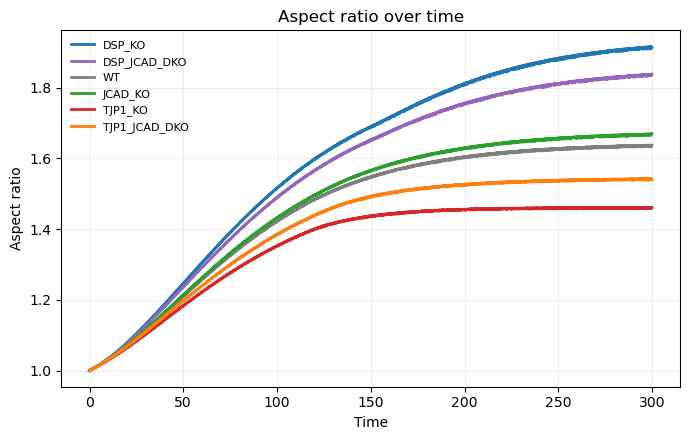

In [10]:
plot_ar_timeseries(cell_ts_df, ABM_SIM_FIG_DIR)


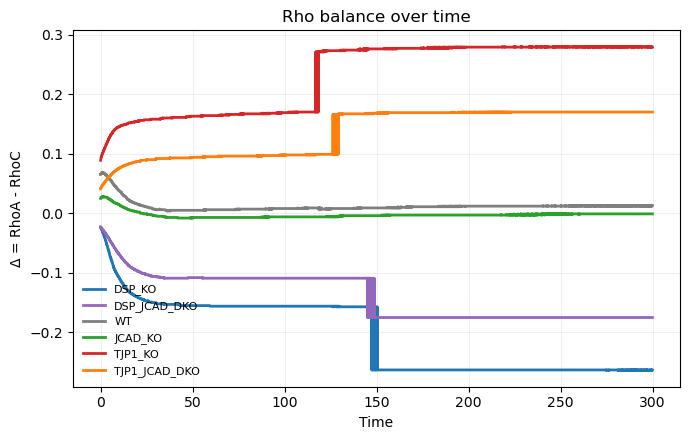

In [11]:
plot_rho_balance_timeseries(cell_ts_df, ABM_SIM_FIG_DIR)


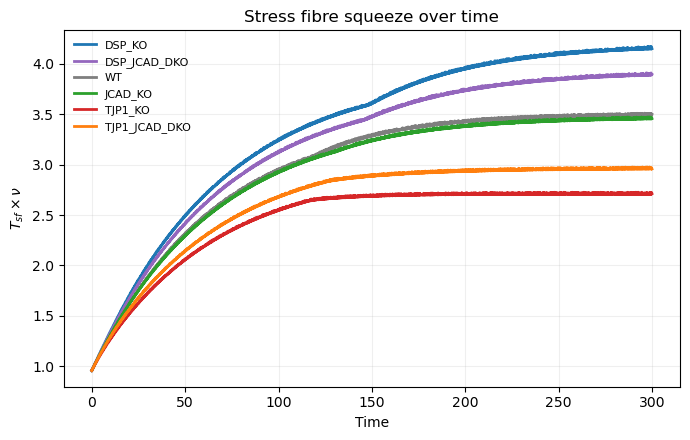

In [12]:
plot_squeeze_timeseries(cell_ts_df, ABM_SIM_FIG_DIR)

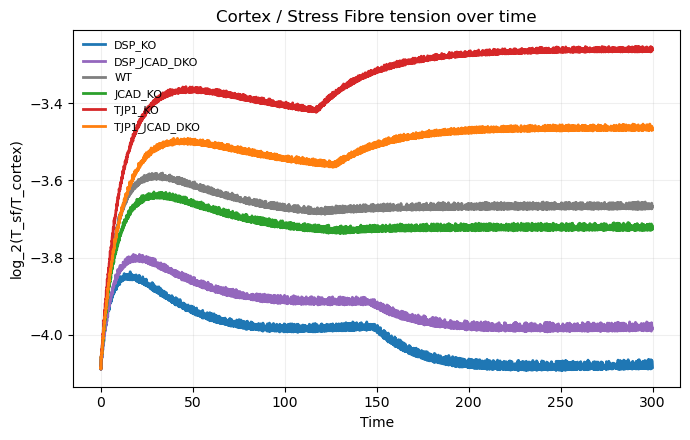

In [13]:
plot_tensions_balance_timeseries(cell_ts_df, ABM_SIM_FIG_DIR)